## **Estimating Employees**

## **1. Setup**

In [96]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_pinball_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from quantile_forest import RandomForestQuantileRegressor
import matplotlib.pyplot as plt
%matplotlib inline

parent_dir = Path.cwd().parent
sys.path.append(f'{parent_dir}/py_modules')

from data_cleaner import DataCleaner
from LTMFinancialProcessor import LTMFinancialProcessor
from employee_est_modules import get_feature_report, adversarial_validation, classifier_feature_importance, score

In [97]:
RANDOM_STATE = 42

## **2. Load Data**

In [98]:
annual_data = pd.read_excel(f'{parent_dir}/data/Annual Financial Data (No Extra Columns).xlsx')
quarterly_data = pd.read_excel(f'{parent_dir}/data/Quarterly Financial Data (No Extra Columns).xlsx')

**Save Production Function Variables for Later**

In [100]:
identification_columns = ['Fiscal Data Year and Quarter', 'Ticker Symbol', 'NAICS Industry']

production_function_columns = ['Revenue - Total',
                               'Property, Plant and Equipment - Total (Gross)',
                               'Inventories - Total',
                               'Working Capital (Balance Sheet)',
                               'Research and Development Expense',
                               'Intangible Assets - Total',
                               'Depreciation, Depletion and Amortization (Accumulated)',
                               'Depreciation and Amortization',
                               'Inventory - Raw Materials', 
                               'Cost of Goods Sold']

In [101]:
production_function_columns = quarterly_data[identification_columns + production_function_columns]
production_function_columns.reset_index(inplace=True)

## **2. Clean & Filter**
### **2.1 Annual Data**

In [103]:
annual_cleaner = DataCleaner(annual_data, variable_of_interest='Employees')
annual_summary = annual_cleaner.summarize_columns()
annual_correlation_summary = annual_cleaner.correlation()

annual_correlation_summary.rename(columns={'index': 'Variable'}, inplace=True)

annual_correlation_summary = annual_correlation_summary.where(annual_correlation_summary[
    '% Nan Values']<0.5).dropna().sort_values(by='% Nan Values', ascending=False).reset_index()

/Users/alexanderperalta/Desktop/Spring 2026/Projects/Economics Project /venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/alexanderperalta/Desktop/Spring 2026/Projects/Economics Project /venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### **2.2. Quarterly Data**

In [104]:
quarterly_cleaner = DataCleaner(quarterly_data, variable_of_interest='Employees')
quarterly_summary = quarterly_cleaner.summarize_columns()

quarterly_summary = quarterly_summary.where(quarterly_summary[
    '% Nan Values']<0.1).dropna().sort_values(by='% Nan Values', ascending=False).reset_index()

quarterly_columns = list(quarterly_summary['index'].unique())
quarterly_data = quarterly_data[quarterly_columns].dropna()
quarterly_data.drop(columns={'Preferred ESOP Obligation - Total', 
                             'Preferred ESOP Obligation - Redeemable', 
                             'Preferred ESOP Obligation - Non-Redeemable'}, inplace=True)

### **2.3. Align Columns**

In [107]:
len(list(annual_data.columns)) > len(list(quarterly_data.columns))

True

In [ ]:
annual_identifiers = ['Global Company Key', 'Company Name', 'Date', 'Ticker Symbol', 'Employees']

quarterly_dates = {'Fiscal Data Year and Quarter', 'Fiscal Quarter', 'Fiscal Year', 'NAICS Industry'}
quarterly_columns_new = [item for item in quarterly_columns if item not in quarterly_dates]
annual_columns = list(set(annual_identifiers).union(set(quarterly_columns_new)))
annual_data = annual_data[annual_columns].dropna()
annual_data.drop(columns={'Preferred ESOP Obligation - Total', 
                             'Preferred ESOP Obligation - Redeemable', 
                             'Preferred ESOP Obligation - Non-Redeemable'}, inplace=True)

In [111]:
quarterly_identifiers = list(quarterly_dates) + ['Global Company Key', 'Company Name', 'Date', 'Ticker Symbol']

In [112]:
cols1 = set(quarterly_data.columns)
cols2 = set(annual_data.columns)

identical = cols1 == cols2 # Check if columns are identical

missing_in_annual_data = cols1 - cols2 # Find columns in quarterly_data but not in annual_data
print(missing_in_annual_data)

missing_in_quarterly_data = cols2 - cols1 # Find columns in annual_data but not in quarterly_data
print(missing_in_quarterly_data)

{'NAICS Industry', 'Fiscal Year', 'Fiscal Data Year and Quarter', 'Fiscal Quarter'}
{'Employees'}


## **4. Distribution Checks**

### **4.1. Jensen-Shannon Divergence**

Compute the Jensen-Shannon distance (metric) between two probability arrays. This is the square root of the Jensen-Shannon divergence.

The Jensen-Shannon distance between two probability vectors p and q is defined as,

$$\sqrt{\frac{D(p \parallel m) + D(q \parallel m)}{2}}$$

where $m$ is the pointwise mean of $q$ and $d$ and $D$ is the Kullback-Leibler divergence.

This routine will normalize $p$ and $q$ if they don’t sum to 1.0.

In [113]:
stability_report = get_feature_report(annual_data, quarterly_data)
stability_report = stability_report.where(stability_report['Status']=='Drifted').dropna()

stability_report

,Column,JS_Distance,Mean_Diff_Pct,Status


### **4.2. Adversarial Validation (Raw)**

In [114]:
X_test  = quarterly_data.select_dtypes(include=['number']).copy()
X_train = annual_data.select_dtypes(include=['number']).copy()

av1 = adversarial_validation(X_test, X_train)
av1[0]

0    1.0
Name: test-auc-mean, dtype: float64


In [115]:
importance_df = classifier_feature_importance(av1)

### **4.3. Feature Engineering**

In [116]:
q_processor = LTMFinancialProcessor(quarterly_data, mode='quarterly')
quarterly_data = q_processor.calculate_ratios()

a_processor = LTMFinancialProcessor(annual_data, mode='annual')
annual_data = a_processor.calculate_ratios()

### **4.4. Adversarial validation (engineered)**

In [117]:
annual_data = annual_data[list(annual_data.iloc[:, -15:].columns) + annual_identifiers].dropna()
quarterly_data = quarterly_data[list(quarterly_data.iloc[:, -15:].columns) + quarterly_identifiers].dropna()

In [119]:
X_test  = quarterly_data.iloc[:, :-8].select_dtypes(include=['number']).copy()
X_train = annual_data.iloc[:, :-5].select_dtypes(include=['number']).copy()

av2 = adversarial_validation(X_test, X_train)
av2[0]

67    0.552937
Name: test-auc-mean, dtype: float64


In [120]:
importance_df = classifier_feature_importance(av2)
importance_df

,Feature,Importance
0,Receivables Intensity,491.0
1,Current Liabilities Mix,386.0
2,Accrual Ratio,384.0
3,Current Ratio,366.0
4,Cash Coverage,339.0
5,Equity Multiplier,307.0
6,Inventory Intensity,304.0
7,Depreciation Intensity,292.0
8,Intangibles Ratio,286.0
9,Log_Assets,282.0


## **5. Model: Quantile Regression Forest**

### **5.1. Train/calib/test split**

In [121]:
X = annual_data.drop(columns=annual_identifiers[:-1])
X = X.drop(["Employees"], axis=1)
y = np.log1p(annual_data["Employees"])

assert X.isna().sum().sum() == 0

X_train_full_raw, X_test, y_train_full_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train_raw, X_calib, y_train_raw, y_calib = train_test_split(X_train_full_raw, y_train_full_raw, test_size=0.2, random_state=RANDOM_STATE)

train_combined = pd.concat([X_train_raw, y_train_raw], axis=1)
train_resampled = train_combined.sample(n=5000, replace=True, random_state=RANDOM_STATE)

X_train = train_resampled.drop(["Employees"], axis=1)
y_train = train_resampled["Employees"]

print(f"Train shape: {X_train.shape}")
print(f"Calibration shape: {X_calib.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (5000, 15)
Calibration shape: (969, 15)
Test shape: (1211, 15)


### **5.2. Fit & predict**

In [122]:
qrf = RandomForestQuantileRegressor(n_estimators=1000, 
                                    max_depth=7,
                                    min_samples_leaf=10)
qrf.fit(X_train, y_train)

coverage_percent = 90
alpha = (100-coverage_percent)/100

y_pred_lower_upper = qrf.predict(X_test, quantiles=[alpha/2, 1-alpha/2])
y_pred = qrf.predict(X_test, quantiles=[0.5]) # Predict the median instead of the mean to correct for Pinball Los

In [123]:
predictions = pd.DataFrame(y_test.values, columns = ['y_true'])
predictions["lower"] = y_pred_lower_upper[:,0]
predictions["point prediction"] = y_pred
predictions["upper"] = y_pred_lower_upper[:,1]
predictions

,y_true,lower,point prediction,upper
0,0.096219,0.039173,0.123102,0.273837
1,1.308333,0.336472,0.663203,1.328665
2,2.967950,2.140066,2.714695,3.158701
3,0.489806,0.201307,1.073807,1.969627
4,0.014889,0.013903,0.043059,0.118672
...,...,...,...,...
1206,3.784190,3.088954,3.788715,4.394449
1207,0.544647,0.444686,0.772420,1.253190
1208,2.197225,1.200868,1.757858,2.251292
1209,0.732368,0.279146,0.730443,0.993252


### **5.3. Evaluation (coverage, MWIS, pinball, residuals)**

let us now plot the predictions and their corresponding prediction intervals:

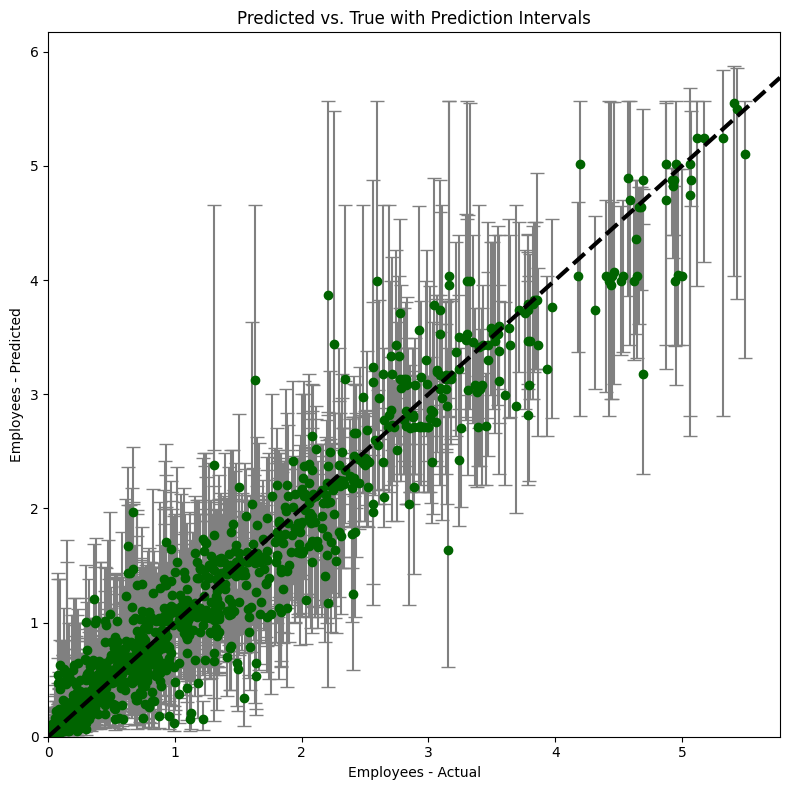

In [124]:
lower_errors = np.maximum(predictions["point prediction"] - predictions["lower"], 0)
upper_errors = np.maximum(predictions["upper"] - predictions["point prediction"], 0)

fig, ax = plt.subplots(figsize=(8, 8))

plt.errorbar(predictions["y_true"], predictions["point prediction"],
             yerr=[lower_errors, upper_errors],
             color='darkgreen', ecolor='grey', linestyle='', marker="o", capsize=5)

ax.axline([0, 0], [1, 1], color="black", linestyle='--', lw=3, zorder=3)
plt.xlim(0)
plt.ylim(0)
plt.xlabel('Employees - Actual')
plt.ylabel('Employees - Predicted')
plt.title("Predicted vs. True with Prediction Intervals")
plt.tight_layout()
plt.show()

#### Error plot (sorted by prediction interval width)

In [125]:
predictions["error"] = predictions["point prediction"] - predictions["y_true"]

predictions["error_upper"] = (predictions["upper"] - predictions["point prediction"])
predictions["error_lower"] = -(predictions["point prediction"]- predictions["lower"])

predictions["interval_width"] = predictions["upper"] - predictions["lower"]
sorted_predictions = predictions.sort_values(by=['interval_width']).reset_index(drop=True)

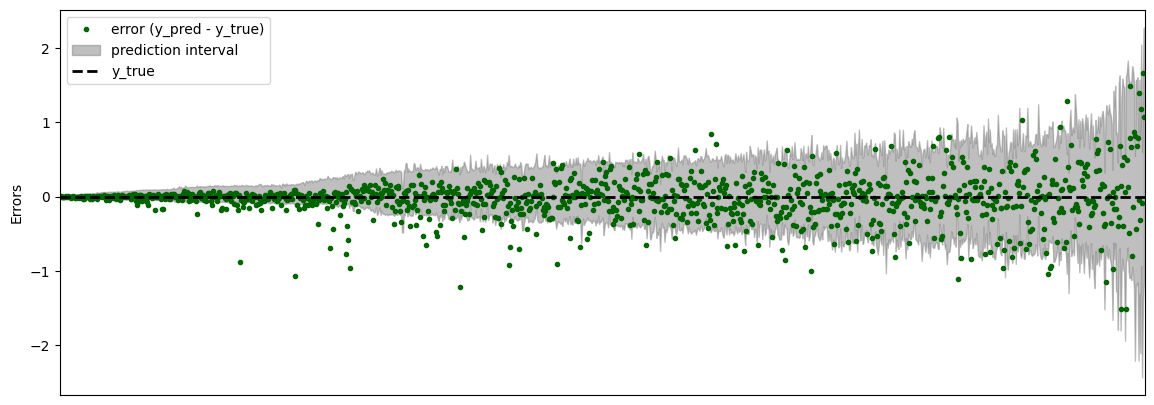

In [126]:
fig, ax = plt.subplots(figsize=(14, 5))

plt.plot(sorted_predictions["error"], 'o', markersize=3, label="error (y_pred - y_true)", color='darkgreen')

plt.fill_between(np.arange(len(sorted_predictions)),
                 sorted_predictions["error_lower"], 
                 sorted_predictions["error_upper"], 
                 alpha=0.5, color="grey", label="prediction interval")

ax.axline([0, 0], [1, 0], color = "black", linestyle='--', lw=2, zorder=3, label="y_true")
plt.xticks([])
plt.xlim([0, len(sorted_predictions)])
plt.ylabel("Errors", fontsize=10)
plt.legend(loc="upper left", fontsize=10)
plt.show()

Calculate the % of predictions that are within the predicttion interval

In [127]:
sorted_predictions["is_outside_range"] = 0
sorted_predictions["is_outside_range"] = sorted_predictions["is_outside_range"].where((
    (sorted_predictions["error"] < sorted_predictions["error_upper"]) & (sorted_predictions["error"] > sorted_predictions["error_lower"]) ), 
    other=1)

print(round(100-(100/len(sorted_predictions))*sorted_predictions["is_outside_range"].sum(),1))

87.0


Now let us calculate the % of prediction intervals that contained the ground truth value

In [128]:
sorted_predictions["gt_within_PI"] = 0
sorted_predictions["gt_within_PI"] = sorted_predictions["gt_within_PI"].where((
    (sorted_predictions["y_true"] < sorted_predictions["upper"]) & (sorted_predictions["y_true"] > sorted_predictions["lower"]) ), 
    other=1)

print(round(100-(100/len(sorted_predictions))*sorted_predictions["gt_within_PI"].sum(),1))

90.9


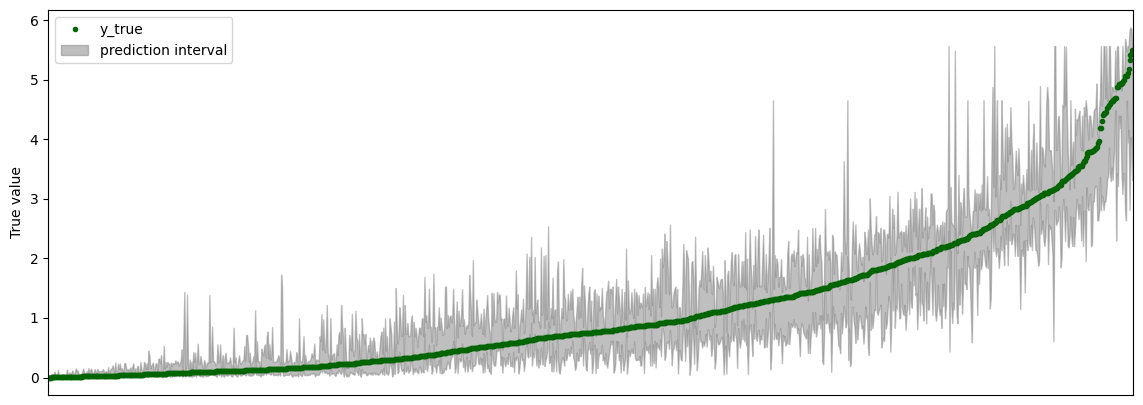

In [129]:
sorted_predictions = predictions.sort_values(by=['y_true']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))

plt.plot(sorted_predictions["y_true"], 'o', markersize=3, label="y_true", color='darkgreen')

plt.fill_between(np.arange(len(sorted_predictions)),
                 sorted_predictions["lower"], 
                 sorted_predictions["upper"], 
                 alpha=0.5, color="grey", label="prediction interval")

plt.xticks([])
plt.xlim([0, len(sorted_predictions)])
plt.ylabel("True value")
plt.legend(loc="upper left", fontsize=10)
plt.show()

Average prediction interval width

In [130]:
print(round(predictions["interval_width"].mean(),-3))
print(round(predictions["interval_width"].median(),-3))

0.0
0.0


In [131]:
MWIS,coverage = score(predictions["y_true"],predictions["lower"],predictions["upper"],alpha)
print(f"MWI score",round(MWIS,3))
print("Predictions coverage", round(coverage*100,1),"%")

MWI score 1.09
Predictions coverage 91.1 %


## **6. Conformal Calibration**
Let us now add *validity* to the prediction intervals using the [conformalized quantile regression (CQR)](https://arxiv.org/pdf/1905.03222.pdf) technique by Emmanuel Candès and co-workers [3].
This is an inductive technique so we shall now make use of the calibration set that we set aside earlier. First we make our predictions for the lower ($l$) and upper ($u$) quantiles in this calibration dataset, just as before


In [132]:
y_pred_lower_upper = qrf.predict(X_calib, quantiles=[alpha/2, 1-alpha/2])

calibration_df = pd.DataFrame(y_calib.values, columns = ['y_true'])
calibration_df["lower"] = y_pred_lower_upper[:,0]
calibration_df["upper"] = y_pred_lower_upper[:,1]

we now calculate the *conformity scores* for each row
$$ E_i := \max \{l_i - y_{true(i)}, y_{true(i)} - u_i \}$$

In [133]:
a  = (calibration_df["lower"]-calibration_df["y_true"]).values
b  = (calibration_df["y_true"]-calibration_df["upper"]).values
calibration_df["Ei"] = (np.vstack((a, b)).T).max(axis=1)

calibration_df

,y_true,lower,upper,Ei
0,1.116452,0.434376,1.969627,-0.682076
1,0.179818,0.045881,0.251537,-0.071718
2,0.431133,0.101654,0.739554,-0.308421
3,0.306749,0.521498,1.486343,0.214749
4,0.936093,0.582774,2.553577,-0.353319
...,...,...,...,...
964,0.085260,0.045881,0.261595,-0.039379
965,1.210452,0.917430,1.931280,-0.293022
966,0.045929,0.013903,0.106160,-0.032026
967,0.727549,0.168054,0.863079,-0.135531


now we calculate a score $s$ as the following quantile of the $E_i$ values:
$$ s = \mathrm{quantile} \left( (1-\alpha)(1+1/n) \right) $$
where $n$ is the number of rows in the calibration set

In [134]:
s = calibration_df["Ei"].quantile((1-alpha)*(1+(1/(len(calibration_df)))))
print(s)

-0.004762647817680669


then finally we subtract $s$ from the lower quantile we calculated earlier for the test set, and we add $s$ to the upper quantile

In [135]:
predictions["conformal_lower"] = predictions["lower"] - s
predictions["conformal_upper"] = predictions["upper"] + s

predictions

,y_true,lower,point prediction,upper,error,error_upper,error_lower,interval_width,conformal_lower,conformal_upper
0,0.096219,0.039173,0.123102,0.273837,0.026883,0.150734,-0.083930,0.234664,0.043935,0.269074
1,1.308333,0.336472,0.663203,1.328665,-0.645130,0.665462,-0.326731,0.992193,0.341235,1.323903
2,2.967950,2.140066,2.714695,3.158701,-0.253255,0.444006,-0.574629,1.018635,2.144829,3.153938
3,0.489806,0.201307,1.073807,1.969627,0.584001,0.895820,-0.872500,1.768320,0.206070,1.964864
4,0.014889,0.013903,0.043059,0.118672,0.028171,0.075612,-0.029157,0.104769,0.018666,0.113909
...,...,...,...,...,...,...,...,...,...,...
1206,3.784190,3.088954,3.788715,4.394449,0.004525,0.605735,-0.699761,1.305495,3.093717,4.389687
1207,0.544647,0.444686,0.772420,1.253190,0.227773,0.480769,-0.327735,0.808504,0.449448,1.248427
1208,2.197225,1.200868,1.757858,2.251292,-0.439367,0.493434,-0.556990,1.050424,1.205631,2.246529
1209,0.732368,0.279146,0.730443,0.993252,-0.001925,0.262809,-0.451297,0.714106,0.283908,0.988489


now let us take a look at the new coverage

In [136]:
MWIS,coverage = score(predictions["y_true"],predictions["conformal_lower"],predictions["conformal_upper"],alpha)
print(f"MWI score",round(MWIS,3))
print("Predictions coverage", round(coverage*100,1),"%")

MWI score 1.09
Predictions coverage 89.8 %


   Alpha  Pinball Loss
0    0.1      0.040135
1    0.2      0.063617
2    0.3      0.079584
3    0.4      0.088906
4    0.5      0.093361
5    0.6      0.091563
6    0.7      0.087686
7    0.8      0.074530
8    0.9      0.050337
Calculated Mean Bias: 0.025724


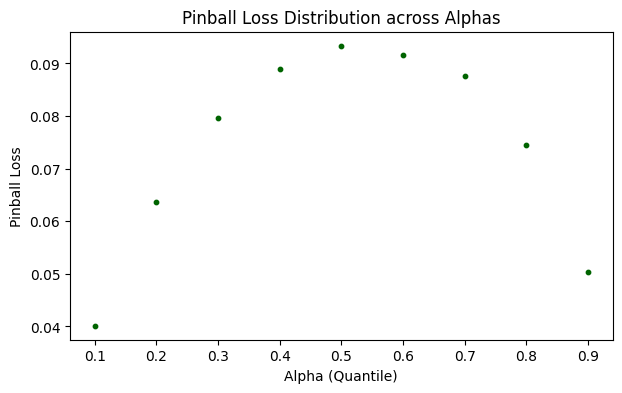

In [137]:
y_true = predictions["y_true"]

alphas = np.linspace(0.1, 0.9, 9)
loss_list = []

for a in alphas:
    y_pred_quantile = qrf.predict(X_test, quantiles=[a])
    loss = mean_pinball_loss(y_true, y_pred_quantile, alpha=a)
    loss_list.append(loss)

pinball_loss_df = {'Alpha': alphas,
                   'Pinball Loss': loss_list}

median_pred = qrf.predict(X_test, quantiles=[0.5])
mean_error = np.mean(y_true - median_pred)
pinball_loss_df = pd.DataFrame(pinball_loss_df)
print(pinball_loss_df)
print(f"Calculated Mean Bias: {mean_error:.6f}")

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.scatter(pinball_loss_df['Alpha'], pinball_loss_df['Pinball Loss'], s=10, color='darkgreen')

ax.set_xlabel('Alpha (Quantile)')
ax.set_ylabel('Pinball Loss')
ax.set_title('Pinball Loss Distribution across Alphas')

plt.show()

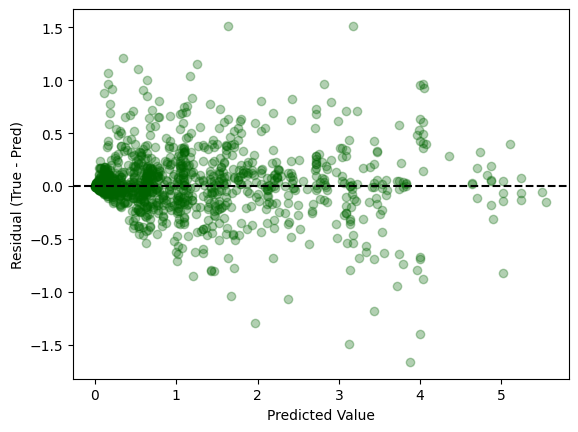

In [138]:
# Plot Residuals vs. Predicted Value (on Calibration or Test data)
residuals = predictions["y_true"] - predictions["point prediction"]
plt.scatter(predictions["point prediction"], residuals, alpha=0.3, color='darkgreen')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted Value")
plt.ylabel("Residual (True - Pred)")
plt.show()

## **7. Predict on Quarterly Set**

In [139]:
X_train_columns = list(X_train.columns)

In [140]:
X_new = quarterly_data[X_train_columns]

In [141]:
quantiles = [alpha/2, 1 - alpha/2]
pred_new_lower_upper = qrf.predict(X_new, quantiles=quantiles)
pred_new_point = qrf.predict(X_new, quantiles=[0.5])

In [142]:
pred_new_conformal_lower = pred_new_lower_upper[:, 0] - s
pred_new_conformal_upper = pred_new_lower_upper[:, 1] + s

In [143]:
quarterly_data["Employees_pred_point"] = pred_new_point
quarterly_data["Employees_pred_lower"] = pred_new_conformal_lower
quarterly_data["Employees_pred_upper"] = pred_new_conformal_upper

In [144]:
# Build a classifier to distinguish between X_train and X_new
X_combined = pd.concat([X_train, X_new])
y_combined = [0] * len(X_train) + [1] * len(X_new)

clf = RandomForestClassifier()
accuracy = cross_val_score(clf, X_combined, y_combined, cv=5).mean()
print("Classifier accuracy:", accuracy)

Classifier accuracy: 0.6218454871595254


## **8. Export**

In [145]:
quarterly_data = quarterly_data.dropna(subset=['Employees_pred_point'])

In [146]:
quarterly_data.reset_index(inplace=True)
quarterly_data = pd.merge(left=quarterly_data, right=production_function_columns, how='inner', on='index')
quarterly_data.drop(columns='index', inplace=True)

In [147]:
emp_cols = ['Employees_pred_point', 'Employees_pred_lower', 'Employees_pred_upper']
quarterly_data[emp_cols] = np.expm1(quarterly_data[emp_cols])

In [148]:
quarterly_data = quarterly_data[['Company Name',
                                 'Ticker Symbol_x',
                                 'Fiscal Data Year and Quarter_x',
                                 'Date',
                                 'Fiscal Quarter',
                                 'Fiscal Year',
                                 'Global Company Key',
                                 'NAICS Industry_x',
                                 'Revenue - Total',
                                 'Property, Plant and Equipment - Total (Gross)',
                                 'Inventories - Total',
                                 'Working Capital (Balance Sheet)',
                                 'Research and Development Expense',
                                 'Intangible Assets - Total',
                                 'Depreciation, Depletion and Amortization (Accumulated)',
                                 'Depreciation and Amortization',
                                 'Inventory - Raw Materials',
                                 'Cost of Goods Sold',
                                 'Employees_pred_point',
                                 'Employees_pred_lower',
                                 'Employees_pred_upper',
                                 'Log_Assets',
                                 'Log_Revenue',
                                 'SGA Intensity',
                                 'COGS Efficiency',
                                 'Depreciation Intensity',
                                 'Debt to Equity Ratio',
                                 'Equity Multiplier',
                                 'Debt Ratio',
                                 'Current Liabilities Mix',
                                 'Current Ratio',
                                 'Inventory Intensity',
                                 'Cash Coverage',
                                 'Intangibles Ratio',
                                 'Receivables Intensity',
                                 'Accrual Ratio']].copy()

quarterly_data.rename(columns={'Ticker Symbol_x': 'Ticker Symbol',
                                'Fiscal Data Year and Quarter_x': 'Fiscal Data Year and Quarter', 
                                'NAICS Industry_x': 'NAICS Industry'},
                                inplace=True)

In [149]:
quarterly_data.to_excel(f'{parent_dir}/output/Quarterly Data (with Employees).xlsx')

In [ ]:
quarterly_data.

,Company Name,Ticker Symbol,Fiscal Data Year and Quarter,Date,Fiscal Quarter,Fiscal Year,Global Company Key,NAICS Industry,Revenue - Total,"Property, Plant and Equipment - Total (Gross)",...,Debt to Equity Ratio,Equity Multiplier,Debt Ratio,Current Liabilities Mix,Current Ratio,Inventory Intensity,Cash Coverage,Intangibles Ratio,Receivables Intensity,Accrual Ratio
0,BK TECHNOLOGIES CORP,BKTI,2010Q4,2010-12-31,4,2010,1117,Radio and Television Broadcasting and Wireless...,5.375,4.993,...,0.068957,1.162911,0.140089,0.763810,6.179135,0.423757,1.686755,0.110078,0.191543,0.024994
1,BK TECHNOLOGIES CORP,BKTI,2011Q1,2011-03-31,1,2011,1117,Radio and Television Broadcasting and Wireless...,6.714,NaN,...,0.080081,1.200482,0.167001,0.684005,5.879459,0.473760,1.537451,0.108719,0.153188,0.030976
2,BK TECHNOLOGIES CORP,BKTI,2011Q2,2011-06-30,2,2011,1117,Radio and Television Broadcasting and Wireless...,4.671,NaN,...,0.081749,1.228648,0.186097,0.605316,6.037365,0.515600,1.358115,0.105415,0.144474,0.031272
3,BK TECHNOLOGIES CORP,BKTI,2011Q3,2011-09-30,3,2011,1117,Radio and Television Broadcasting and Wireless...,6.976,NaN,...,0.064881,1.227226,0.185154,0.583994,6.366019,0.539031,1.340350,0.099905,0.131771,0.034658
4,BK TECHNOLOGIES CORP,BKTI,2011Q4,2011-12-31,4,2011,1117,Radio and Television Broadcasting and Wireless...,5.743,5.208,...,0.000000,1.204172,0.169554,0.629559,6.536314,0.545769,1.222035,0.094623,0.135619,0.037585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18787,SAVERONE 2014 LTD,SVRE,2022Q4,2022-12-31,4,2022,338703,Other Measuring and Controlling Device Manufac...,0.127,0.570,...,0.006413,1.277105,0.216979,0.810891,5.433128,0.028788,5.027560,0.000000,0.019441,-0.595087
18788,SAVERONE 2014 LTD,SVRE,2023Q2,2023-06-30,2,2023,338703,Other Measuring and Controlling Device Manufac...,0.397,NaN,...,0.000000,1.496157,0.331621,0.867404,3.312794,0.059649,2.892955,0.000000,0.033971,-0.548092
18789,SAVERONE 2014 LTD,SVRE,2023Q4,2023-12-31,4,2023,338703,Other Measuring and Controlling Device Manufac...,0.358,0.906,...,0.047839,1.622301,0.383592,0.896135,2.781992,0.085251,2.352283,0.000000,0.034378,-0.343560
18790,SAVERONE 2014 LTD,SVRE,2024Q2,2024-06-30,2,2024,338703,Other Measuring and Controlling Device Manufac...,0.128,NaN,...,0.054044,1.923609,0.480144,0.899750,2.166744,0.152667,1.625212,0.000000,0.051529,-0.363903
